1. data (prepare and load) -- Dataset, DataLoader,torchvision.transform
2. build model -- torch.nn.Module, torchvision.models, torch.optim (optimizer)
3. fitting the model with data (training)
4. making predictions and evaluating a model (inference) -- torchmetrics
5. improve through experimentation -- tensorboard
6. saving and loading a model

In [5]:
# checking the contents of our PyTorch model - what is inside?
# check .parameters()

import torch
import torch.nn as nn

In [6]:
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weight * x + self.bias

In [8]:
torch.manual_seed(42)
model_0 = LinearRegressionModel()
model_0

LinearRegressionModel()

In [10]:
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [11]:
# list named parameters
model_0.state_dict()

OrderedDict([('weight', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
 # what we expect, the ideal values: weight = 0.7, bias = 0.3
 # usually we dont know them

### making prediction using `torch.inference_mode()`

to see our model's prediction power, let's see how well it predicts `y_test` based on `X_test`.

When we pass data through our model, it's going to run it through the `forward()` method.

In [17]:
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = 0.7 * X + 0.3
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

X_test, y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [15]:
# make prediction with model

with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

In [18]:
from matplotlib import pyplot as plt


def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    # plot training data in blue
    plt.scatter(train_data, train_labels, s=4, color='b', label='Training data')
    # plot training data in green
    plt.scatter(test_data, test_labels, s=4, color='y', label='Testing data')
    # are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, s=4, color='r', label='Predictions')

    # show the legend
    plt.legend(prop={'size': 14})

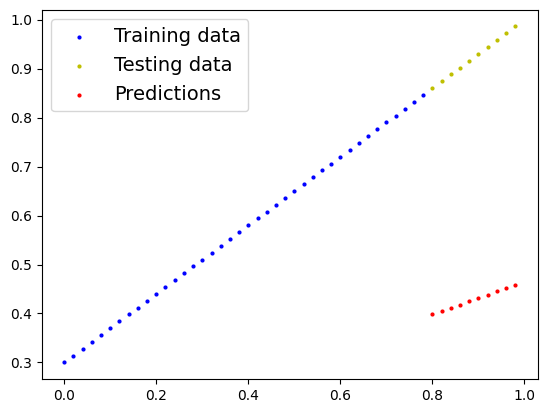

In [19]:
 # random values
plot_predictions(predictions=y_preds)
y_preds = model_0(X_test)

```
with torch.inference_mode():
    y_preds = model_0(X_test)
```

This is a context manager.

In [23]:
# without context manager: we have an inference tracking.
# (context manager turns off the inference. when we don't do training,
# we don't need to keep track of gradient, how to update the model)

# the benefit to use context manager: keep track of less data

y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

# Train model

The idea of training is for a model to move from unknown parameters (random values) to some known parameters.

One way to measure is to use loss function.

https://docs.pytorch.org/docs/stable/nn.html#loss-functions

In [ ]:
# 5:44:00